In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import Row

spark = SparkSession.builder.appName("DataPrepGuide").getOrCreate()

data = [
    Row(ID=101, NAME="Alice",   AGE=25,   SALARY=50000.0,      DEPARTMENT="Engineering"),
    Row(ID=101, NAME="Alice",   AGE=25,   SALARY=50000.0,      DEPARTMENT="Engineering"), # Duplicate
    Row(ID=102, NAME="BOB",     AGE=30,   SALARY=float("nan"), DEPARTMENT="HR"),          # NaN salary
    Row(ID=103, NAME=None,      AGE=None, SALARY=45000.0,      DEPARTMENT=None),          # Null name, age, dept
    Row(ID=104, NAME="Tom",     AGE=None, SALARY=float("nan"), DEPARTMENT="Sales"),       # Null age, NaN salary
    Row(ID=105, NAME="Jerry",   AGE=22,   SALARY=35000.0,      DEPARTMENT="Marketing"),
    Row(ID=106, NAME="Josh",    AGE=40,   SALARY=999999.0,     DEPARTMENT="Engineering"), # Outlier salary
    Row(ID=107, NAME="Bush",    AGE=-5,   SALARY=60000.0,      DEPARTMENT="HR"),          # Invalid negative age
    Row(ID=108, NAME="claire",  AGE=29,   SALARY=None,         DEPARTMENT="Sales"),       # Null salary
    Row(ID=109, NAME="David",   AGE=35,   SALARY=70000.0,      DEPARTMENT="Finance")
]

df = spark.createDataFrame(data)
df.show()


+---+------+----+--------+-----------+
| ID|  NAME| AGE|  SALARY| DEPARTMENT|
+---+------+----+--------+-----------+
|101| Alice|  25| 50000.0|Engineering|
|101| Alice|  25| 50000.0|Engineering|
|102|   BOB|  30|     NaN|         HR|
|103|  NULL|NULL| 45000.0|       NULL|
|104|   Tom|NULL|     NaN|      Sales|
|105| Jerry|  22| 35000.0|  Marketing|
|106|  Josh|  40|999999.0|Engineering|
|107|  Bush|  -5| 60000.0|         HR|
|108|claire|  29|    NULL|      Sales|
|109| David|  35| 70000.0|    Finance|
+---+------+----+--------+-----------+



In [4]:
df.columns

['ID', 'NAME', 'AGE', 'SALARY', 'DEPARTMENT']

In [6]:
df.printSchema()

root
 |-- ID: long (nullable = true)
 |-- NAME: string (nullable = true)
 |-- AGE: long (nullable = true)
 |-- SALARY: double (nullable = true)
 |-- DEPARTMENT: string (nullable = true)



# Data Preparation
## 1. Standardizing Column Names (withColumnRenamed)

In [7]:
# Convert column names to lowercase
df_cleaned = df
for col_name in df.columns:
    df_cleaned = df_cleaned.withColumnRenamed(col_name, col_name.lower())

df_cleaned.printSchema()


root
 |-- id: long (nullable = true)
 |-- name: string (nullable = true)
 |-- age: long (nullable = true)
 |-- salary: double (nullable = true)
 |-- department: string (nullable = true)



## 2. Detecting Missing Values (NULL and NaN)

In [8]:
# Count NaN and Null across all columns
missing_counts = df_cleaned.select([
    F.count(
        F.when(F.isnan(c) | F.col(c).isNull(), c) 
        if dtype in ("double", "float") 
        else F.when(F.col(c).isNull(), c)
    ).alias(c)
    for c, dtype in df_cleaned.dtypes
])

missing_counts.show()


+---+----+---+------+----------+
| id|name|age|salary|department|
+---+----+---+------+----------+
|  0|   1|  2|     3|         1|
+---+----+---+------+----------+



## Step 3: Dropping Missing Values (DataFrame.dropna / DataFrame.na.drop)

In [9]:
# 1. Drop rows where key identifier ('id' or 'name') is missing
# (Records without a valid name are generally unusable)
df_no_null_id = df_cleaned.dropna(subset=["name"])

df_no_null_id.show()


+---+------+----+--------+-----------+
| id|  name| age|  salary| department|
+---+------+----+--------+-----------+
|101| Alice|  25| 50000.0|Engineering|
|101| Alice|  25| 50000.0|Engineering|
|102|   BOB|  30|     NaN|         HR|
|104|   Tom|NULL|     NaN|      Sales|
|105| Jerry|  22| 35000.0|  Marketing|
|106|  Josh|  40|999999.0|Engineering|
|107|  Bush|  -5| 60000.0|         HR|
|108|claire|  29|    NULL|      Sales|
|109| David|  35| 70000.0|    Finance|
+---+------+----+--------+-----------+



In [10]:
# 2. How the parameters work:
# - how="any": drops if ANY listed column is Null/NaN (default)
# - how="all": drops only if ALL listed columns are Null/NaN
# - subset: list of specific columns to evaluate
df_valid_records = df_cleaned.dropna(how="all", subset=["age", "salary"])

df_valid_records.show()

+---+------+----+--------+-----------+
| id|  name| age|  salary| department|
+---+------+----+--------+-----------+
|101| Alice|  25| 50000.0|Engineering|
|101| Alice|  25| 50000.0|Engineering|
|102|   BOB|  30|     NaN|         HR|
|103|  NULL|NULL| 45000.0|       NULL|
|105| Jerry|  22| 35000.0|  Marketing|
|106|  Josh|  40|999999.0|Engineering|
|107|  Bush|  -5| 60000.0|         HR|
|108|claire|  29|    NULL|      Sales|
|109| David|  35| 70000.0|    Finance|
+---+------+----+--------+-----------+



In [12]:
# Dropping missing names for the next steps:
df_step3 = df_cleaned.dropna(subset=["name"])

df_step3.show()

+---+------+----+--------+-----------+
| id|  name| age|  salary| department|
+---+------+----+--------+-----------+
|101| Alice|  25| 50000.0|Engineering|
|101| Alice|  25| 50000.0|Engineering|
|102|   BOB|  30|     NaN|         HR|
|104|   Tom|NULL|     NaN|      Sales|
|105| Jerry|  22| 35000.0|  Marketing|
|106|  Josh|  40|999999.0|Engineering|
|107|  Bush|  -5| 60000.0|         HR|
|108|claire|  29|    NULL|      Sales|
|109| David|  35| 70000.0|    Finance|
+---+------+----+--------+-----------+



## Step 4: Imputing Missing Values (DataFrame.fillna / DataFrame.na.fill)

In [14]:
# Pass a dictionary specifying replacements per column
df_filled = df_step3.na.fill({
    "age": 0,
    "salary": 30000.0,
    "department": "Unknown"
})

df_filled.show()

+---+------+---+--------+-----------+
| id|  name|age|  salary| department|
+---+------+---+--------+-----------+
|101| Alice| 25| 50000.0|Engineering|
|101| Alice| 25| 50000.0|Engineering|
|102|   BOB| 30| 30000.0|         HR|
|104|   Tom|  0| 30000.0|      Sales|
|105| Jerry| 22| 35000.0|  Marketing|
|106|  Josh| 40|999999.0|Engineering|
|107|  Bush| -5| 60000.0|         HR|
|108|claire| 29| 30000.0|      Sales|
|109| David| 35| 70000.0|    Finance|
+---+------+---+--------+-----------+



In [15]:
# Compute mean age and median/mean salary (excluding nulls/nans automatically)
stats = df_step3.select(
    F.round(F.avg("age")).alias("mean_age"),
    F.round(F.avg("salary"), 2).alias("mean_salary")
).first()

mean_age = int(stats["mean_age"])
mean_salary = float(stats["mean_salary"])

# Impute computed averages
df_imputed = df_step3.na.fill({
    "age": mean_age,
    "salary": mean_salary,
    "department": "Unassigned"
})
df_imputed.show()


+---+------+---+--------+-----------+
| id|  name|age|  salary| department|
+---+------+---+--------+-----------+
|101| Alice| 25| 50000.0|Engineering|
|101| Alice| 25| 50000.0|Engineering|
|102|   BOB| 30|     NaN|         HR|
|104|   Tom| 25|     NaN|      Sales|
|105| Jerry| 22| 35000.0|  Marketing|
|106|  Josh| 40|999999.0|Engineering|
|107|  Bush| -5| 60000.0|         HR|
|108|claire| 29|     NaN|      Sales|
|109| David| 35| 70000.0|    Finance|
+---+------+---+--------+-----------+



## Step 5: Removing Outliers (where / filter)

In [16]:
# Filter realistic age bounds (0 < age <= 100) and salary bounds (20,000 to 200,000)
df_filtered = df_imputed.where(
    (F.col("age").between(18, 100)) & 
    (F.col("salary").between(20000.0, 200000.0))
)
df_filtered.show()


+---+-----+---+-------+-----------+
| id| name|age| salary| department|
+---+-----+---+-------+-----------+
|101|Alice| 25|50000.0|Engineering|
|101|Alice| 25|50000.0|Engineering|
|105|Jerry| 22|35000.0|  Marketing|
|109|David| 35|70000.0|    Finance|
+---+-----+---+-------+-----------+



## Step 6: Removing Duplicates (distinct / dropDuplicates)

In [17]:
# Option A: Full-row deduplication using distinct()
df_dedup = df_filtered.distinct()

# Option B: Deduplication based on specific primary key (id)
df_dedup = df_filtered.dropDuplicates(subset=["id"])
df_dedup.show()


+---+-----+---+-------+-----------+
| id| name|age| salary| department|
+---+-----+---+-------+-----------+
|101|Alice| 25|50000.0|Engineering|
|105|Jerry| 22|35000.0|  Marketing|
|109|David| 35|70000.0|    Finance|
+---+-----+---+-------+-----------+



## Step 7: String Manipulation and Formatting

In [18]:
df_final = df_dedup.withColumn("name", F.initcap(F.trim(F.col("name")))) \
                   .withColumn("department", F.upper(F.trim(F.col("department"))))

df_final.show()


+---+-----+---+-------+-----------+
| id| name|age| salary| department|
+---+-----+---+-------+-----------+
|101|Alice| 25|50000.0|ENGINEERING|
|105|Jerry| 22|35000.0|  MARKETING|
|109|David| 35|70000.0|    FINANCE|
+---+-----+---+-------+-----------+



# Arithmatic Function

In [19]:
# from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import Row

spark = SparkSession.builder.appName("ArithmeticExample").getOrCreate()

# Sample data: base salary, performance score, bonus rate, and expense claims
data = [
    Row(name="Alice",  base_salary=60000.0, bonus_rate=0.10, claims=1200.0, hours_worked=2000),
    Row(name="Bob",    base_salary=50000.0, bonus_rate=0.08, claims=0.0,    hours_worked=1900),
    Row(name="Claire", base_salary=80000.0, bonus_rate=0.15, claims=3500.0, hours_worked=2100),
    Row(name="David",  base_salary=45000.0, bonus_rate=0.05, claims=500.0,  hours_worked=1800),
    Row(name="Eva",    base_salary=70000.0, bonus_rate=0.12, claims=2100.0, hours_worked=2050),
]

df = spark.createDataFrame(data)

# Common arithmetic operations
df_math = df \
    .withColumn("bonus_amount", F.col("base_salary") * F.col("bonus_rate")) \
    .withColumn("gross_pay", F.col("base_salary") + F.col("bonus_amount") + F.col("claims")) \
    .withColumn("tax_deduction", F.round(F.col("gross_pay") * 0.20, 2)) \
    .withColumn("net_pay", F.round(F.col("gross_pay") - F.col("tax_deduction"), 2)) \
    .withColumn("hourly_rate", F.round(F.col("gross_pay") / F.col("hours_worked"), 2))

df_math.select(
    "name",
    "base_salary",
    "bonus_amount",
    "tax_deduction",
    "net_pay",
    "hourly_rate"
).show()


+------+-----------+------------+-------------+-------+-----------+
|  name|base_salary|bonus_amount|tax_deduction|net_pay|hourly_rate|
+------+-----------+------------+-------------+-------+-----------+
| Alice|    60000.0|      6000.0|      13440.0|53760.0|       33.6|
|   Bob|    50000.0|      4000.0|      10800.0|43200.0|      28.42|
|Claire|    80000.0|     12000.0|      19100.0|76400.0|      45.48|
| David|    45000.0|      2250.0|       9550.0|38200.0|      26.53|
|   Eva|    70000.0|      8400.0|      16100.0|64400.0|      39.27|
+------+-----------+------------+-------------+-------+-----------+



# Exploratory Data Analytis
## Step 0: Clean Dataset

In [21]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import Row

spark = SparkSession.builder.appName("PySparkEDA").getOrCreate()

clean_data = [
    Row(order_id=1, category="Electronics", region="North", sales=1200.0, units=2, discount=0.05, rating=4.5),
    Row(order_id=2, category="Electronics", region="East",  sales=850.0,  units=1, discount=0.00, rating=4.0),
    Row(order_id=3, category="Furniture",   region="North", sales=450.0,  units=3, discount=0.15, rating=3.8),
    Row(order_id=4, category="Office",      region="South", sales=150.0,  units=5, discount=0.20, rating=4.2),
    Row(order_id=5, category="Electronics", region="West",  sales=2100.0, units=3, discount=0.10, rating=4.9),
    Row(order_id=6, category="Furniture",   region="East",  sales=600.0,  units=2, discount=0.05, rating=3.5),
    Row(order_id=7, category="Office",      region="West",  sales=95.0,   units=4, discount=0.00, rating=4.1),
    Row(order_id=8, category="Furniture",   region="South", sales=1100.0, units=4, discount=0.25, rating=4.0),
    Row(order_id=9, category="Electronics", region="North", sales=950.0,  units=1, discount=0.00, rating=4.7),
    Row(order_id=10, category="Office",     region="East",  sales=320.0,  units=8, discount=0.10, rating=3.9),
]

df = spark.createDataFrame(clean_data)
df.show(5)

+--------+-----------+------+------+-----+--------+------+
|order_id|   category|region| sales|units|discount|rating|
+--------+-----------+------+------+-----+--------+------+
|       1|Electronics| North|1200.0|    2|    0.05|   4.5|
|       2|Electronics|  East| 850.0|    1|     0.0|   4.0|
|       3|  Furniture| North| 450.0|    3|    0.15|   3.8|
|       4|     Office| South| 150.0|    5|     0.2|   4.2|
|       5|Electronics|  West|2100.0|    3|     0.1|   4.9|
+--------+-----------+------+------+-----+--------+------+
only showing top 5 rows



## Step 1: Overall Numerical Distribution (describe & summary)

In [22]:
# Detailed statistical summary including percentiles
df.select("sales", "units", "rating").summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max").show()

+-------+-----------------+-----------------+------------------+
|summary|            sales|            units|            rating|
+-------+-----------------+-----------------+------------------+
|  count|               10|               10|                10|
|   mean|            781.5|              3.3|              4.16|
| stddev|603.1401624461395|2.110818693198342|0.4273952113286564|
|    min|             95.0|                1|               3.5|
|    25%|            320.0|                2|               3.9|
|    50%|            600.0|                3|               4.0|
|    75%|           1100.0|                4|               4.5|
|    max|           2100.0|                8|               4.9|
+-------+-----------------+-----------------+------------------+



## Step 2: Categorical Distributions (Bar Chart Ready)
### For categorical features, count occurrences and compute aggregate revenue per segment.

In [23]:
# Aggregating sales by category
cat_summary = df.groupBy("category").agg(
    F.count("order_id").alias("order_count"),
    F.round(F.sum("sales"), 2).alias("total_sales"),
    F.round(F.avg("sales"), 2).alias("avg_order_value")
).orderBy(F.col("total_sales").desc())

cat_summary.show()


+-----------+-----------+-----------+---------------+
|   category|order_count|total_sales|avg_order_value|
+-----------+-----------+-----------+---------------+
|Electronics|          4|     5100.0|         1275.0|
|  Furniture|          3|     2150.0|         716.67|
|     Office|          3|      565.0|         188.33|
+-----------+-----------+-----------+---------------+



## Step 3: Two-Dimensional Breakdown / Heatmap (pivot)
### Cross-tabulating metrics across two dimensions (e.g., category vs region) creates a pivot table ready for a heatmap.

In [24]:
# Total sales by category across different regions
region_pivot = df.groupBy("category") \
    .pivot("region") \
    .agg(F.round(F.sum("sales"), 2)) \
    .na.fill(0)

region_pivot.show()

+-----------+-----+------+------+------+
|   category| East| North| South|  West|
+-----------+-----+------+------+------+
|     Office|320.0|   0.0| 150.0|  95.0|
|Electronics|850.0|2150.0|   0.0|2100.0|
|  Furniture|600.0| 450.0|1100.0|   0.0|
+-----------+-----+------+------+------+



## Step 4: Correlation Analysis (Scatter Matrix Ready)
### Evaluate linear relationships between continuous variables using stat.corr:

In [25]:
numeric_cols = ["sales", "units", "discount", "rating"]

# Print correlation pairs
for i in range(len(numeric_cols)):
    for j in range(i + 1, len(numeric_cols)):
        col1, col2 = numeric_cols[i], numeric_cols[j]
        corr_val = df.stat.corr(col1, col2)
        print(f"Correlation between {col1:8} and {col2:8}: {corr_val:.4f}")


Correlation between sales    and units   : -0.4058
Correlation between sales    and discount: 0.0024
Correlation between sales    and rating  : 0.6561
Correlation between units    and discount: 0.4689
Correlation between units    and rating  : -0.2315
Correlation between discount and rating  : -0.1603


## Step 5: Visualizing the Aggregations (Pandas / Matplotlib / Seaborn)
### Golden Rule of PySpark Visualization: Never call .toPandas() on raw distributed big data. Always aggregate, filter, or sample in PySpark first, then pull the small, aggregated summary into Pandas for plotting.

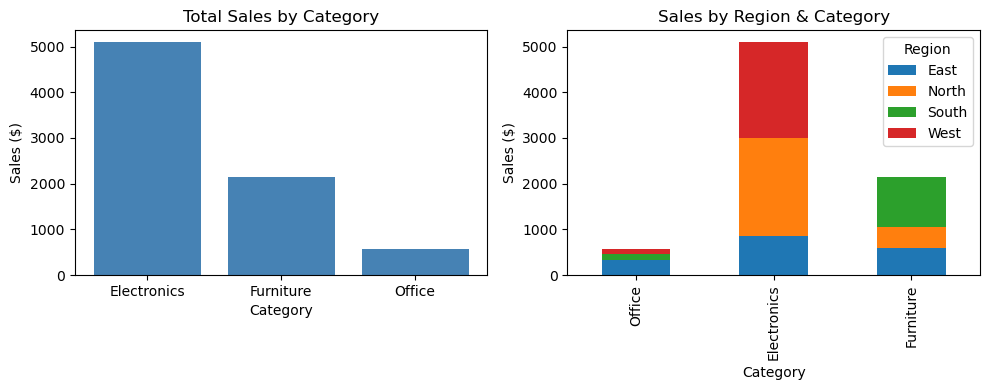

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Convert only the aggregated summary to Pandas
pdf_category = cat_summary.toPandas()
pdf_pivot = region_pivot.toPandas().set_index("category")

# 2. Plotting Bar Chart (Category Sales)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(pdf_category["category"], pdf_category["total_sales"], color="steelblue")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")

# 3. Plotting Stacked Bar (Sales by Category across Regions)
plt.subplot(1, 2, 2)
pdf_pivot.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Sales by Region & Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")
plt.legend(title="Region")

plt.tight_layout()
plt.show()


# EDA - Distribution of Data
## Step 0: Generate the Sample Data (10 Records, 5 Columns)
#### To keep it concrete with 10 records and 5 columns, we model an e-commerce metrics table:
#### normal_height: Bell-shaped, symmetric values centered around 170 cm.
#### skew_right_income: Most values cluster low ($30k–$60k), with extreme high earners pulling the right tail ($150k, $250k).
#### skew_left_exam_score: An easy exam where most students score 85–98, but a few low performers pull the left tail (42, 55).

In [27]:
# from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import Row

spark = SparkSession.builder.appName("DistributionAnalysis").getOrCreate()

data = [
    Row(user_id=1,  segment="A", normal_height=170.0, skew_right_income=32000.0,  skew_left_exam_score=95.0),
    Row(user_id=2,  segment="B", normal_height=165.0, skew_right_income=38000.0,  skew_left_exam_score=88.0),
    Row(user_id=3,  segment="A", normal_height=175.0, skew_right_income=42000.0,  skew_left_exam_score=92.0),
    Row(user_id=4,  segment="C", normal_height=162.0, skew_right_income=45000.0,  skew_left_exam_score=42.0), # Low tail
    Row(user_id=5,  segment="B", normal_height=178.0, skew_right_income=49000.0,  skew_left_exam_score=90.0),
    Row(user_id=6,  segment="C", normal_height=168.0, skew_right_income=52000.0,  skew_left_exam_score=85.0),
    Row(user_id=7,  segment="A", normal_height=172.0, skew_right_income=58000.0,  skew_left_exam_score=55.0), # Low tail
    Row(user_id=8,  segment="B", normal_height=171.0, skew_right_income=65000.0,  skew_left_exam_score=97.0),
    Row(user_id=9,  segment="A", normal_height=160.0, skew_right_income=150000.0, skew_left_exam_score=94.0), # High tail
    Row(user_id=10, segment="C", normal_height=180.0, skew_right_income=250000.0, skew_left_exam_score=98.0)  # High tail
]

df = spark.createDataFrame(data)
df.show()

+-------+-------+-------------+-----------------+--------------------+
|user_id|segment|normal_height|skew_right_income|skew_left_exam_score|
+-------+-------+-------------+-----------------+--------------------+
|      1|      A|        170.0|          32000.0|                95.0|
|      2|      B|        165.0|          38000.0|                88.0|
|      3|      A|        175.0|          42000.0|                92.0|
|      4|      C|        162.0|          45000.0|                42.0|
|      5|      B|        178.0|          49000.0|                90.0|
|      6|      C|        168.0|          52000.0|                85.0|
|      7|      A|        172.0|          58000.0|                55.0|
|      8|      B|        171.0|          65000.0|                97.0|
|      9|      A|        160.0|         150000.0|                94.0|
|     10|      C|        180.0|         250000.0|                98.0|
+-------+-------+-------------+-----------------+--------------------+



## Step 1: Detect Skewness Statistically in PySpark
#### Before plotting, PySpark provides F.skewness() and F.kurtosis():
#### Skewness ≈ 0: Symmetric / Normal
#### Skewness > 0: Right-skewed (positive tail)

#### Skewness < 0: Left-skewed (negative tail)

In [28]:
stats_df = df.select(
    F.round(F.skewness("normal_height"), 2).alias("skew_height"),
    F.round(F.skewness("skew_right_income"), 2).alias("skew_income"),
    F.round(F.skewness("skew_left_exam_score"), 2).alias("skew_exam")
)

stats_df.show()


+-----------+-----------+---------+
|skew_height|skew_income|skew_exam|
+-----------+-----------+---------+
|      -0.05|       1.83|    -1.44|
+-----------+-----------+---------+



### skew_height = 0.04: Extremely close to 0 (bell curve/symmetric).
### skew_income = 1.88: Strong positive skew (long right tail).
### skew_exam = -1.58: Strong negative skew (long left tail).

## Step 2: Compare Mean vs. Median (Quick Diagnostic)
#### A quick rule of thumb for distributions:
- Normal: Mean ‭$\approx$‬ Median
- Right Skew: Mean ‭$>$‬ Median (extreme large values pull the average up)
- Left Skew: Mean ‭$<$‬ Median (extreme low values pull the average down)

In [29]:
mean_median_check = df.select(
    # Normal column
    F.round(F.avg("normal_height"), 1).alias("height_mean"),
    F.percentile_approx("normal_height", 0.5).alias("height_median"),
    # Right-skewed column
    F.round(F.avg("skew_right_income"), 1).alias("income_mean"),
    F.percentile_approx("skew_right_income", 0.5).alias("income_median"),
    # Left-skewed column
    F.round(F.avg("skew_left_exam_score"), 1).alias("exam_mean"),
    F.percentile_approx("skew_left_exam_score", 0.5).alias("exam_median")
)

mean_median_check.show()

+-----------+-------------+-----------+-------------+---------+-----------+
|height_mean|height_median|income_mean|income_median|exam_mean|exam_median|
+-----------+-------------+-----------+-------------+---------+-----------+
|      170.1|        170.0|    78100.0|      49000.0|     83.6|       90.0|
+-----------+-------------+-----------+-------------+---------+-----------+



## Step 3: Plot the Distributions
### Convert the target columns into Pandas to visualize both histogram shape and Kernel Density Estimation (KDE):

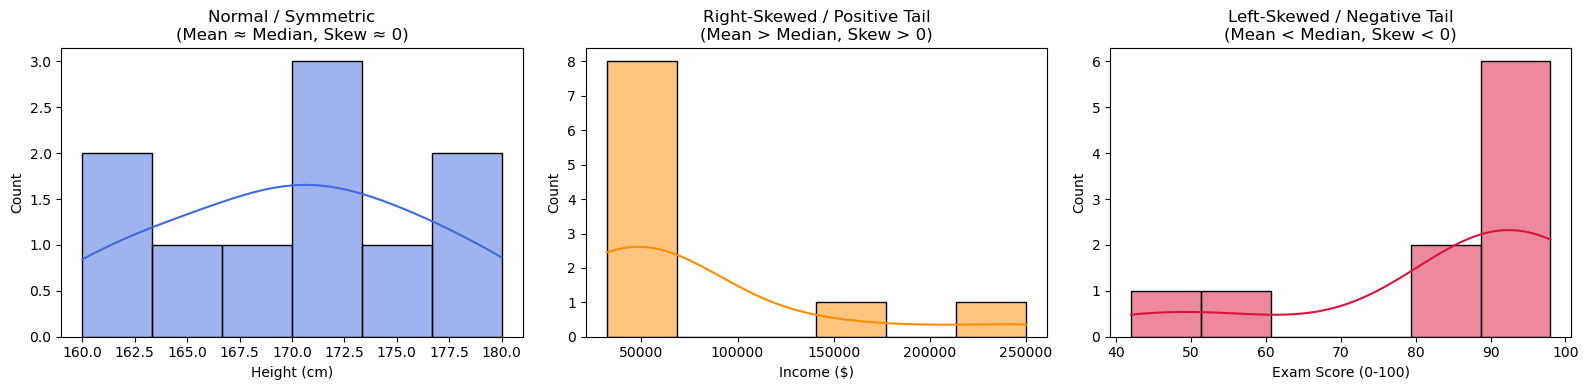

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pull only the numerical columns for plotting
pdf = df.select("normal_height", "skew_right_income", "skew_left_exam_score").toPandas()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Normal Distribution (Symmetric)
sns.histplot(pdf["normal_height"], kde=True, ax=axes[0], color="royalblue", bins=6)
axes[0].set_title("Normal / Symmetric\n(Mean ≈ Median, Skew ≈ 0)")
axes[0].set_xlabel("Height (cm)")

# 2. Right-Skewed (Positive Skew)
sns.histplot(pdf["skew_right_income"], kde=True, ax=axes[1], color="darkorange", bins=6)
axes[1].set_title("Right-Skewed / Positive Tail\n(Mean > Median, Skew > 0)")
axes[1].set_xlabel("Income ($)")

# 3. Left-Skewed (Negative Skew)
sns.histplot(pdf["skew_left_exam_score"], kde=True, ax=axes[2], color="crimson", bins=6)
axes[2].set_title("Left-Skewed / Negative Tail\n(Mean < Median, Skew < 0)")
axes[2].set_xlabel("Exam Score (0-100)")

plt.tight_layout()
plt.show()


### Why Skewness Matters for Your Pipeline
1. Imputation Choice: For normal distributions, fill missing values with the mean. For skewed columns, always use the median because the mean is biased by extreme outliers.
2. Model Performance: Machine learning algorithms (like linear regression or neural networks) assume normally distributed inputs. Right-skewed features are typically stabilized using F.log1p("skew_right_income") (log transformation) before feeding them to a model.

In [31]:
spark.stop()